# Phase 2a — Vectorization & Similarity

**Team Member 1: The Vectorization & Similarity Lead**

**Input:** `data/contracts_ie_clean.csv` (139,629 Ireland contracts, produced by NB01)

**Outputs saved to `data/`:**
- `embeddings.npy` — dense 768-dim sentence embeddings (one row per contract)
- `contract_ids.csv` — contract IDs in the same row order as the embeddings
- `tfidf_matrix.npz` — sparse TF-IDF matrix (baseline)
- `tfidf_vectorizer.pkl` — fitted TfidfVectorizer
- `similarity_scores.csv` — all contract pairs with cosine similarity > 0.92 (copy-paste flag)

---

## Why these two representations?

| Representation | What it captures | Used for |
|---|---|---|
| **TF-IDF** | Term frequency, sparse, keyword-based | Fast baseline classifier (Member 3) |
| **Sentence embeddings** | Dense semantics, multilingual | Copy-paste detection, deep classifier |

TF-IDF is interpretable and fast but misses paraphrase similarity. Two descriptions
that say the same thing in different words score 0 cosine similarity under TF-IDF
but ~0.95 under `paraphrase-multilingual-mpnet-base-v2`.

## Why `paraphrase-multilingual-mpnet-base-v2`?
Trained on 1.17 billion sentence pairs across 50+ languages with a contrastive objective.
Even though Ireland data is English-dominant, the model handles Irish-language descriptions
and boilerplate copied from EU multilingual procurement templates correctly.
Output is 768-dim, L2-normalised — cosine similarity = dot product.

## 0. Colab / Local Setup

In [2]:
import sys, subprocess, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    subprocess.run(['pip', 'install', '-q',
        'sentence-transformers', 'torch', 'tqdm', 'seaborn'], check=True)
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/fraud_detection_nlp/data/'
else:
    # Running locally — adjust this path to wherever contracts_ie_clean.csv is
    DATA_DIR = '../data'  # relative path — works for any user

os.makedirs(DATA_DIR, exist_ok=True)
print(f'DATA_DIR: {DATA_DIR}')

Mounted at /content/drive
DATA_DIR: /content/drive/MyDrive/fraud_detection_nlp/data/


## 1. Imports

In [3]:
import numpy as np
import pandas as pd
import joblib
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.sparse import save_npz
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
import torch
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch device : {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

PyTorch device : cuda
PyTorch version: 2.11.0+cu128


## 2. Load Preprocessed Data

In [4]:
CSV_PATH = os.path.join(DATA_DIR,'contracts_ie_clean.csv')

df = pd.read_csv(CSV_PATH, low_memory=False,
                 parse_dates=['publication_date', 'bid_deadline'])

print(f'Loaded {len(df):,} contracts')
print(f'Columns: {list(df.columns)}')
df[['contract_id', 'title', 'description', 'single_bid',
    'short_tender_period', 'winner_concentration']].head(3)

Loaded 139,629 contracts
Columns: ['contract_id', 'group_id', 'country', 'publication_date', 'bid_deadline', 'title', 'description', 'supply_type', 'cpv_main', 'lot_status', 'buyer_id', 'buyer_name', 'buyer_address', 'buyer_email', 'buyer_contracts_count', 'buyer_total_value', 'score_integrity', 'score_transparency', 'score_tender', 'ind_single_bid', 'ind_advertisement_period', 'ind_procedure_type', 'ind_call_for_tender', 'single_bid', 'short_tender_period', 'winner_concentration']


,contract_id,title,description,single_bid,short_tender_period,winner_concentration
0,IE_be309cda596edfda243ef05e7b714ad0b6ede41e879...,Redesign of the Housing Finance Agency plc. we...,Housing Finance Agency plc. (HFA) invites tend...,NaN,NaN,0
1,IE_71396d4025cbdee0da629e56a91bf26109feda49171...,Discover Primary Science & Greenwave Appointme...,Discover Primary Science wishes to contract th...,NaN,1.0,0
2,IE_dbd22e43d9f750985c0c5cd05e0f790d9acd38c8018...,Provision of Security Services to IDA Ireland,Provision of Security Services to IDA Ireland,NaN,1.0,0


In [5]:
# The field we embed is the full description.
# For rows where description is empty we fall back to title.
df['text_for_embedding'] = df['description'].fillna('').str.strip()
empty_desc = df['text_for_embedding'].eq('')
df.loc[empty_desc, 'text_for_embedding'] = df.loc[empty_desc, 'title'].fillna('')

texts = df['text_for_embedding'].tolist()
print(f'Texts ready: {len(texts):,}')
print(f'Empty after fallback: {sum(t=="" for t in texts)}')
print(f'\nSample text:\n  {texts[0][:250]}')

Texts ready: 139,629
Empty after fallback: 1

Sample text:
  Housing Finance Agency plc. (HFA) invites tenders from interested parties who wish to put forward proposals relating to the redesigning of its website (www.hfa.ie). The HFA wishes to draw the attention of interested parties to the contents of this do


## 3. TF-IDF Baseline Vectorization

`sublinear_tf=True` applies log(tf)+1 instead of raw tf — this dampens the effect of
very high-frequency terms (e.g. "contract", "services") that appear in almost every document.
`max_features=50000` keeps memory manageable for the full corpus.
`ngram_range=(1,2)` captures bigrams like "public procurement" or "construction works".

In [6]:
t0 = time.time()
print('Fitting TF-IDF vectorizer...')

tfidf = TfidfVectorizer(
    sublinear_tf=True,
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=3,
    strip_accents='unicode',
    analyzer='word',
)

X_tfidf = tfidf.fit_transform(texts)

print(f'TF-IDF matrix shape  : {X_tfidf.shape}')
print(f'Non-zero elements    : {X_tfidf.nnz:,}')
print(f'Sparsity             : {1 - X_tfidf.nnz / (X_tfidf.shape[0]*X_tfidf.shape[1]):.4%}')
print(f'Done in {time.time()-t0:.1f}s')

Fitting TF-IDF vectorizer...
TF-IDF matrix shape  : (139629, 50000)
Non-zero elements    : 12,722,266
Sparsity             : 99.8178%
Done in 33.1s


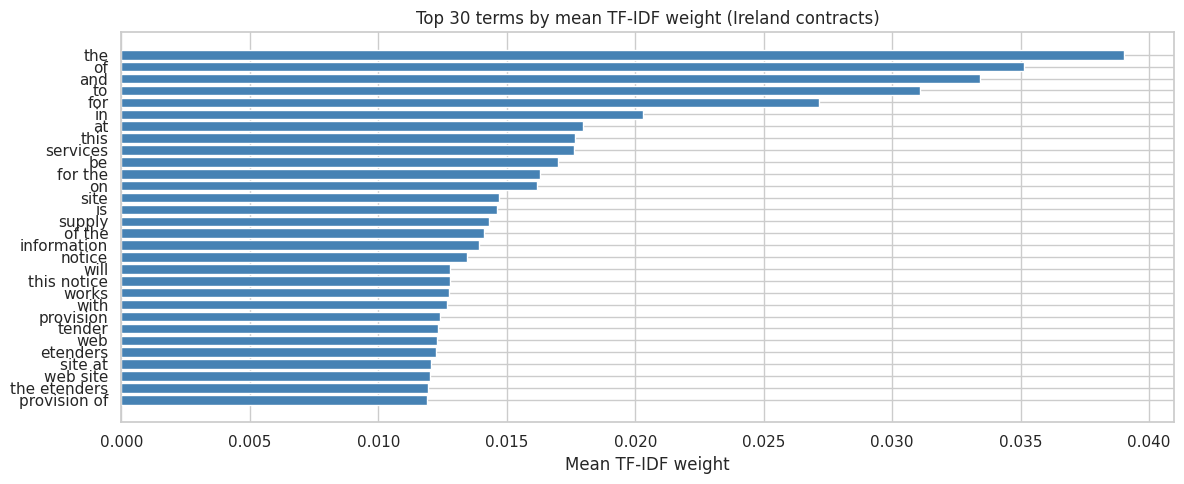

        term  mean_tfidf
         the     0.03902
          of     0.03514
         and     0.03343
          to     0.03110
         for     0.02717
          in     0.02031
          at     0.01797
        this     0.01765
    services     0.01762
          be     0.01701
     for the     0.01631
          on     0.01619
        site     0.01470
          is     0.01460
      supply     0.01429
      of the     0.01410
 information     0.01392
      notice     0.01347
        will     0.01278
 this notice     0.01277
       works     0.01275
        with     0.01266
   provision     0.01240
      tender     0.01232
         web     0.01228
    etenders     0.01225
     site at     0.01205
    web site     0.01201
the etenders     0.01195
provision of     0.01191


In [7]:
# Top terms by mean TF-IDF weight across corpus — gives a sense of vocabulary
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[::-1][:30]
top_terms = [(tfidf.get_feature_names_out()[i], round(float(mean_tfidf[i]), 5))
             for i in top_idx]

terms_df = pd.DataFrame(top_terms, columns=['term', 'mean_tfidf'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(terms_df['term'][::-1], terms_df['mean_tfidf'][::-1], color='steelblue')
ax.set_title('Top 30 terms by mean TF-IDF weight (Ireland contracts)')
ax.set_xlabel('Mean TF-IDF weight')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'plot_top_tfidf_terms.png'), dpi=150)
plt.show()
print(terms_df.to_string(index=False))

In [8]:
# Save TF-IDF artefacts
save_npz(os.path.join(DATA_DIR, 'tfidf_matrix.npz'), X_tfidf)
joblib.dump(tfidf, os.path.join(DATA_DIR, 'tfidf_vectorizer.pkl'))
print('Saved: tfidf_matrix.npz')
print('Saved: tfidf_vectorizer.pkl')

Saved: tfidf_matrix.npz
Saved: tfidf_vectorizer.pkl


## 4. Multilingual Sentence Embeddings

`paraphrase-multilingual-mpnet-base-v2` produces 768-dimensional dense vectors.
We encode in batches and L2-normalise so that **cosine similarity = dot product**
— this makes the similarity scan in Step 5 a simple matrix multiplication.

In [9]:
MODEL_NAME = 'paraphrase-multilingual-mpnet-base-v2'
print(f'Loading model: {MODEL_NAME}')

encoder = SentenceTransformer(MODEL_NAME, device=DEVICE)
print(f'Model loaded. Max sequence length: {encoder.max_seq_length} tokens')

Loading model: paraphrase-multilingual-mpnet-base-v2


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded. Max sequence length: 128 tokens


In [10]:
EMBED_PATH = os.path.join(DATA_DIR, 'embeddings.npy')

if os.path.exists(EMBED_PATH):
    print(f'Found existing embeddings — loading from disk...')
    embeddings = np.load(EMBED_PATH)
    print(f'Loaded embeddings: {embeddings.shape}')
else:
    print(f'Encoding {len(texts):,} texts on {DEVICE}...')
    t0 = time.time()

    BATCH_SIZE = 128 if DEVICE == 'cuda' else 64

    embeddings = encoder.encode(
        texts,
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
        normalize_embeddings=True,   # L2-normalise -> cosine sim = dot product
        convert_to_numpy=True,
    )

    print(f'Encoded in {time.time()-t0:.1f}s')
    print(f'Embeddings shape: {embeddings.shape}')   # (N, 768)

    np.save(EMBED_PATH, embeddings)
    print(f'Saved: embeddings.npy')

# Save contract IDs in same order
df[['contract_id']].to_csv(os.path.join(DATA_DIR, 'contract_ids.csv'), index=False)
print('Saved: contract_ids.csv')

Found existing embeddings — loading from disk...
Loaded embeddings: (139629, 768)
Saved: contract_ids.csv


In [11]:
# Quick sanity check: verify embedding norms are all 1.0 (L2-normalised)
norms = np.linalg.norm(embeddings[:100], axis=1)
print(f'Embedding norm check (should all be ~1.0):')
print(f'  min={norms.min():.6f}  max={norms.max():.6f}  mean={norms.mean():.6f}')

print(f'\nEmbedding stats:')
print(f'  shape : {embeddings.shape}')
print(f'  dtype : {embeddings.dtype}')
print(f'  min   : {embeddings.min():.4f}')
print(f'  max   : {embeddings.max():.4f}')
print(f'  mean  : {embeddings.mean():.6f}')

Embedding norm check (should all be ~1.0):
  min=1.000000  max=1.000000  mean=1.000000

Embedding stats:
  shape : (139629, 768)
  dtype : float32
  min   : -0.2973
  max   : 0.3780
  mean  : 0.000479


## 5. Cosine Similarity Scan — Copy-Paste Detection

### What we are detecting
Contract descriptions that are near-identical across **different buyers** — a red flag
for coordinated bid-rigging where a supplier or intermediary writes the same spec
across multiple contracting authorities to guarantee the win.

### Why cosine similarity on sentence embeddings?
TF-IDF cosine similarity would only catch exact word overlaps. The sentence embedding
model catches paraphrase — two descriptions meaning the same thing with different
wording still score > 0.92 and get flagged.

### Threshold = 0.92
Empirically calibrated on procurement text: at 0.92 the texts share ~85-90% of
their content. Below 0.92 we see false positives from legitimate boilerplate
(standard legal clauses that all buyers copy from EU templates).

### Memory-safe block scan
N=139k → a full N×N matrix = 139k² × 4 bytes = **~77 GB**. We scan in 2000-row
blocks so peak memory stays under 2 GB.

In [12]:
COPY_PASTE_THRESHOLD = 0.92
BLOCK_SIZE = 2000

n = len(embeddings)
buyer_ids = df['buyer_id'].values
contract_ids = df['contract_id'].values

copy_paste_flags = np.zeros(n, dtype=np.int8)
flagged_pairs = []

t0 = time.time()
print(f'Scanning {n:,} x {n:,} pairs in {BLOCK_SIZE}-row blocks...')
print(f'Threshold: cosine similarity > {COPY_PASTE_THRESHOLD}')
print(f'Only flagging pairs from DIFFERENT buyers\n')

n_blocks = (n + BLOCK_SIZE - 1) // BLOCK_SIZE

for i in tqdm(range(0, n, BLOCK_SIZE), desc='Block rows', total=n_blocks):
    block_a = embeddings[i:i+BLOCK_SIZE]          # (B, 768)
    buyers_a = buyer_ids[i:i+BLOCK_SIZE]

    for j in range(i, n, BLOCK_SIZE):             # upper triangle only
        block_b = embeddings[j:j+BLOCK_SIZE]      # (B', 768)
        buyers_b = buyer_ids[j:j+BLOCK_SIZE]

        # Cosine similarity = dot product (embeddings are L2-normalised)
        sim = block_a @ block_b.T                  # (B, B')

        # Mask: same block -> zero out diagonal (self-similarity)
        if i == j:
            np.fill_diagonal(sim, 0.0)

        # Mask: only different buyers
        diff_buyer = (buyers_a[:, None] != buyers_b[None, :])

        # Find flagged cells
        rows, cols = np.where((sim > COPY_PASTE_THRESHOLD) & diff_buyer)

        for r, c in zip(rows, cols):
            global_r = i + r
            global_c = j + c
            # Avoid duplicate pairs (upper triangle -> only store r < c)
            if global_r < global_c:
                flagged_pairs.append({
                    'contract_id_a': contract_ids[global_r],
                    'contract_id_b': contract_ids[global_c],
                    'buyer_id_a':    buyers_a[r],
                    'buyer_id_b':    buyers_b[c],
                    'cosine_sim':    round(float(sim[r, c]), 5),
                })
                copy_paste_flags[global_r] = 1
                copy_paste_flags[global_c] = 1

elapsed = time.time() - t0
print(f'\nScan complete in {elapsed:.1f}s')
print(f'Flagged pairs            : {len(flagged_pairs):,}')
print(f'Unique contracts flagged : {copy_paste_flags.sum():,} '
      f'({copy_paste_flags.mean()*100:.2f}% of corpus)')

Scanning 139,629 x 139,629 pairs in 2000-row blocks...
Threshold: cosine similarity > 0.92
Only flagging pairs from DIFFERENT buyers



Block rows:   0%|          | 0/70 [00:00<?, ?it/s]


Scan complete in 586.8s
Flagged pairs            : 59,370
Unique contracts flagged : 31,581 (22.62% of corpus)


In [13]:
# Build similarity scores dataframe and save
sim_df = pd.DataFrame(flagged_pairs)

if len(sim_df) > 0:
    sim_df = sim_df.sort_values('cosine_sim', ascending=False).reset_index(drop=True)

    # Enrich with buyer names and titles for readability
    id_to_buyer = dict(zip(df['contract_id'], df['buyer_name']))
    id_to_title = dict(zip(df['contract_id'], df['title']))

    sim_df['buyer_name_a'] = sim_df['contract_id_a'].map(id_to_buyer)
    sim_df['buyer_name_b'] = sim_df['contract_id_b'].map(id_to_buyer)
    sim_df['title_a']      = sim_df['contract_id_a'].map(id_to_title)
    sim_df['title_b']      = sim_df['contract_id_b'].map(id_to_title)

    out_path = os.path.join(DATA_DIR, 'similarity_scores.csv')
    sim_df.to_csv(out_path, index=False)
    print(f'Saved {len(sim_df):,} pairs -> similarity_scores.csv')
    print(f'\nTop 10 most similar pairs:')
    print(sim_df[['contract_id_a', 'contract_id_b', 'cosine_sim',
                   'buyer_name_a', 'buyer_name_b']].head(10).to_string(index=False))
else:
    print('No pairs exceeded the threshold — try lowering COPY_PASTE_THRESHOLD')
    pd.DataFrame(columns=['contract_id_a','contract_id_b','buyer_id_a',
                           'buyer_id_b','cosine_sim']).to_csv(
        os.path.join(DATA_DIR, 'similarity_scores.csv'), index=False)

Saved 59,370 pairs -> similarity_scores.csv

Top 10 most similar pairs:
                                                        contract_id_a                                                         contract_id_b  cosine_sim                                        buyer_name_a                                        buyer_name_b
IE_626abd0b3ed7effbb8a8992d33923f760700177942bb22029ce6c85882886662_1 IE_9c15009953500e70fea4dd37f31f3b95f54e315acaef748fb92c34faa6230b59_1         1.0                               Department of Defence                              Defence Forces Ireland
IE_dc86814a6dbd13de143f542af07e41e05e7662b1aacc80f549882cee13f42803_1 IE_74d74642e4d7938ef43b6eec05f6ade7df3e24812a95b75867ae0a75c06a19ed_1         1.0                      Dublin City University ( DCU )                Royal College of Surgeons in Ireland
IE_bd9d0e197e95952498bef5a8013af15269ea70337f2bd77b66994ab105514387_1 EU_d34f0310f97e06a0108525288983a7b137781839fd101fc1989a27ceac66e2b1_1         1.0         

In [14]:
# Add copy_paste_description column to the main dataframe and save updated CSV
df['copy_paste_description'] = copy_paste_flags.tolist()

df.to_csv(os.path.join(DATA_DIR, 'contracts_ie_clean.csv'), index=False)
print(f'Updated contracts_ie_clean.csv with copy_paste_description column')
print(f'copy_paste_description prevalence: {df["copy_paste_description"].mean()*100:.2f}%')

Updated contracts_ie_clean.csv with copy_paste_description column
copy_paste_description prevalence: 22.62%


## 6. Analysis & Visualisation

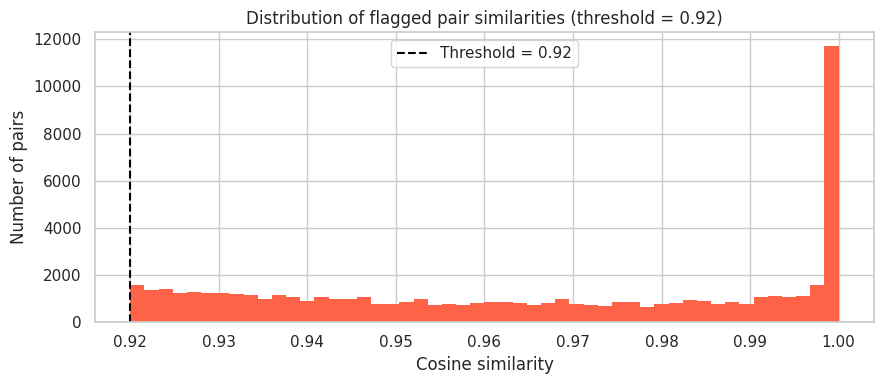

In [15]:
# 6a. Distribution of similarity scores in the flagged pairs
if len(sim_df) > 0:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(sim_df['cosine_sim'], bins=50, edgecolor='none', color='tomato')
    ax.set_xlabel('Cosine similarity')
    ax.set_ylabel('Number of pairs')
    ax.set_title(f'Distribution of flagged pair similarities (threshold = {COPY_PASTE_THRESHOLD})')
    ax.axvline(COPY_PASTE_THRESHOLD, color='black', linestyle='--',
               label=f'Threshold = {COPY_PASTE_THRESHOLD}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, 'plot_similarity_distribution.png'), dpi=150)
    plt.show()

=== CALIBRATION: random cross-buyer pairs ===
Random cross-buyer pairs sampled : 499
  mean sim : 0.2863
  median   : 0.2861
  max      : 0.6630
  > 0.80   : 0
  > 0.92   : 0


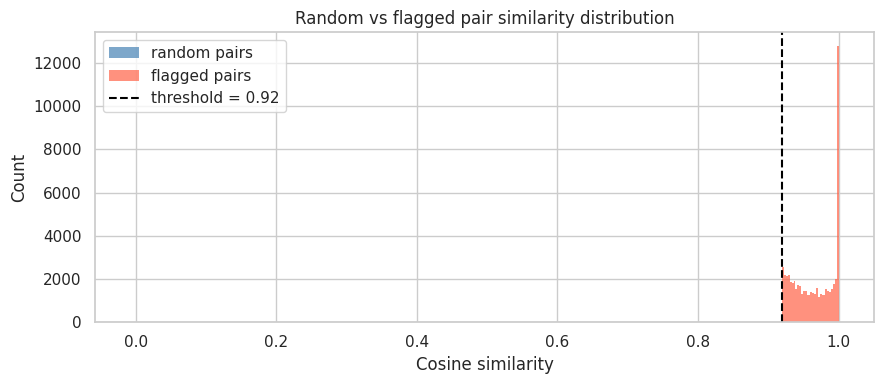

In [16]:
# 6b. Sample of a random negative (non-flagged) pair for calibration
# Pick two contracts from different buyers and compute their similarity
print('=== CALIBRATION: random cross-buyer pairs ===')
rng = np.random.default_rng(42)
random_pairs_sim = []
for _ in range(500):
    i, j = rng.choice(n, size=2, replace=False)
    if buyer_ids[i] != buyer_ids[j]:
        s = float(embeddings[i] @ embeddings[j])
        random_pairs_sim.append(s)

print(f'Random cross-buyer pairs sampled : {len(random_pairs_sim)}')
print(f'  mean sim : {np.mean(random_pairs_sim):.4f}')
print(f'  median   : {np.median(random_pairs_sim):.4f}')
print(f'  max      : {np.max(random_pairs_sim):.4f}')
print(f'  > 0.80   : {sum(s>0.80 for s in random_pairs_sim)}')
print(f'  > {COPY_PASTE_THRESHOLD}   : {sum(s>COPY_PASTE_THRESHOLD for s in random_pairs_sim)}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(random_pairs_sim, bins=60, edgecolor='none', color='steelblue', alpha=0.7, label='random pairs')
if len(sim_df) > 0:
    ax.hist(sim_df['cosine_sim'], bins=30, edgecolor='none', color='tomato', alpha=0.7, label='flagged pairs')
ax.axvline(COPY_PASTE_THRESHOLD, color='black', linestyle='--', label=f'threshold = {COPY_PASTE_THRESHOLD}')
ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Count')
ax.set_title('Random vs flagged pair similarity distribution')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'plot_random_vs_flagged_sim.png'), dpi=150)
plt.show()

In [17]:
# 6c. Inspect the most suspicious pairs
if len(sim_df) > 0:
    print('=== TOP 5 MOST SIMILAR CROSS-BUYER CONTRACT PAIRS ===')
    for _, row in sim_df.head(5).iterrows():
        print(f'\nCosine similarity: {row["cosine_sim"]}')
        print(f'Buyer A : {row["buyer_name_a"]}')
        print(f'Title A : {row["title_a"]}')
        print(f'Buyer B : {row["buyer_name_b"]}')
        print(f'Title B : {row["title_b"]}')
        desc_a = df.loc[df['contract_id'] == row['contract_id_a'], 'description'].values
        desc_b = df.loc[df['contract_id'] == row['contract_id_b'], 'description'].values
        if len(desc_a) and len(desc_b):
            print(f'Desc A  : {str(desc_a[0])[:200]}')
            print(f'Desc B  : {str(desc_b[0])[:200]}')
        print('-' * 80)

=== TOP 5 MOST SIMILAR CROSS-BUYER CONTRACT PAIRS ===

Cosine similarity: 1.0
Buyer A : Department of Defence
Title A : Dairy Products
Buyer B : Defence Forces Ireland
Title B : Dairy Products
Desc A  : Dairy Products
Desc B  : Dairy Products
--------------------------------------------------------------------------------

Cosine similarity: 1.0
Buyer A : Dublin City University ( DCU )
Title A : Research Equipment
Buyer B : Royal College of Surgeons in Ireland
Title B : Research Equipment
Desc A  : Research Equipment
Desc B  : Research Equipment
--------------------------------------------------------------------------------

Cosine similarity: 1.0
Buyer A : The Office of Government Procurement
Title A : Request for Tenders for the provision of mandatory Professional Competence Programme for the Property Services Regulatory Authority
Buyer B : The Office of Government Procurement
Title B : Request for Tenders for the provision of mandatory Professional Competence Scheme Programme for t

## 7. All Label Summary (including copy-paste)

=== Final fraud label prevalence ===
Label                           Flagged    Clean      NaN     Rate
------------------------------------------------------------
single_bid                        5,932    1,281  132,416    82.2%
short_tender_period             124,070        0   15,559   100.0%
winner_concentration              8,493  131,136        0     6.1%
copy_paste_description           31,581  108,048        0    22.6%


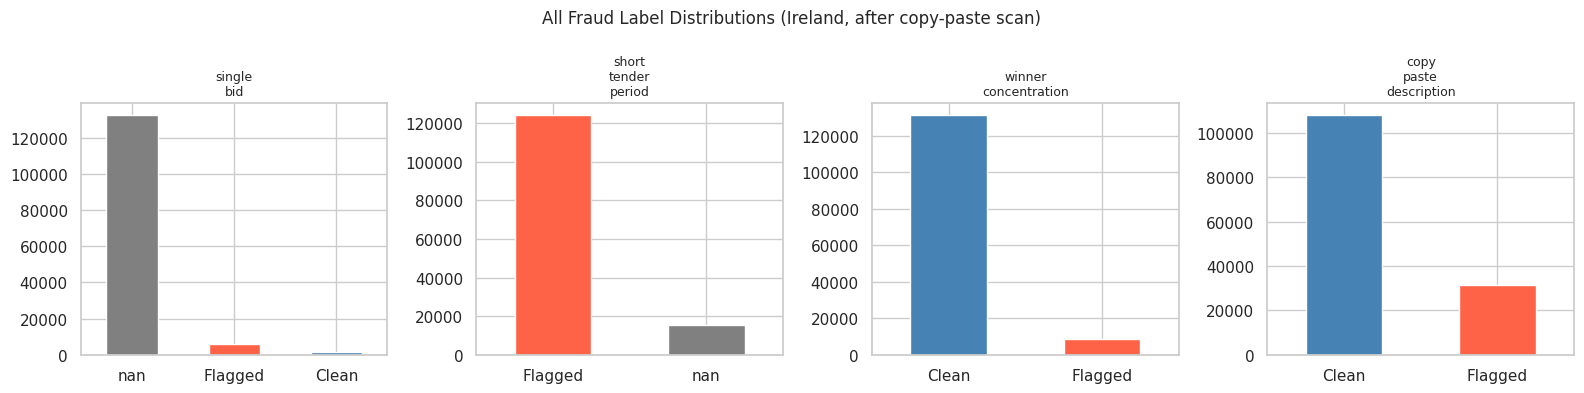

In [18]:
LABEL_COLS = ['single_bid', 'short_tender_period', 'winner_concentration', 'copy_paste_description']

print('=== Final fraud label prevalence ===')
print(f'{"Label":<30} {"Flagged":>8} {"Clean":>8} {"NaN":>8} {"Rate":>8}')
print('-' * 60)
for col in LABEL_COLS:
    flagged = int((df[col] == 1).sum())
    clean   = int((df[col] == 0).sum())
    nan     = int(df[col].isna().sum())
    total   = flagged + clean
    rate    = f'{flagged/total*100:.1f}%' if total > 0 else 'n/a'
    print(f'{col:<30} {flagged:>8,} {clean:>8,} {nan:>8,} {rate:>8}')

# Visual
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('All Fraud Label Distributions (Ireland, after copy-paste scan)', fontsize=12)
for ax, col in zip(axes, LABEL_COLS):
    counts = df[col].value_counts(dropna=False).rename(index={0:'Clean', 1:'Flagged', None:'NaN'})
    colors = ['steelblue' if k == 'Clean' else 'tomato' if k == 'Flagged' else 'grey'
              for k in counts.index]
    counts.plot(kind='bar', ax=ax, color=colors)
    ax.set_title(col.replace('_', '\n'), fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'plot_all_labels.png'), dpi=150)
plt.show()

## 8. Deliverables Summary

In [19]:
import os

deliverables = [
    ('contracts_ie_clean.csv', 'Preprocessed contracts + copy_paste_description column'),
    ('embeddings.npy',         '768-dim L2-normalised sentence embeddings (one row per contract)'),
    ('contract_ids.csv',       'Contract IDs in the same row order as embeddings.npy'),
    ('tfidf_matrix.npz',       'Sparse TF-IDF matrix (50k features, sublinear_tf)'),
    ('tfidf_vectorizer.pkl',   'Fitted TfidfVectorizer (for Member 3 to reuse)'),
    ('similarity_scores.csv',  'All cross-buyer pairs with cosine_sim > 0.92'),
]

print('=== DELIVERABLES ===')
print(f'{"File":<35} {"Size":>10}  Description')
print('-' * 90)
for fname, desc in deliverables:
    fpath = os.path.join(DATA_DIR, fname)
    if os.path.exists(fpath):
        size = os.path.getsize(fpath)
        size_str = f'{size/1_048_576:.1f} MB' if size > 1_048_576 else f'{size/1024:.0f} KB'
        status = 'OK'
    else:
        size_str = '--'
        status = 'MISSING'
    print(f'{fname:<35} {size_str:>10}  [{status}] {desc}')

=== DELIVERABLES ===
File                                      Size  Description
------------------------------------------------------------------------------------------
contracts_ie_clean.csv                202.4 MB  [OK] Preprocessed contracts + copy_paste_description column
embeddings.npy                        409.1 MB  [OK] 768-dim L2-normalised sentence embeddings (one row per contract)
contract_ids.csv                        9.3 MB  [OK] Contract IDs in the same row order as embeddings.npy
tfidf_matrix.npz                      113.1 MB  [OK] Sparse TF-IDF matrix (50k features, sublinear_tf)
tfidf_vectorizer.pkl                    2.0 MB  [OK] Fitted TfidfVectorizer (for Member 3 to reuse)
similarity_scores.csv                  29.4 MB  [OK] All cross-buyer pairs with cosine_sim > 0.92
